In [1]:
import os

# BASE DATASET PATH (already split)
dataset_path = "/kaggle/input/fake-vs-real-dataset/real-vs-fake"

# TRAIN / VAL / TEST PATHS
train_path = os.path.join(dataset_path, "train")
val_path   = os.path.join(dataset_path, "valid")
test_path  = os.path.join(dataset_path, "test")

# CLASS PATHS
train_real = os.path.join(train_path, "real")
train_fake = os.path.join(train_path, "fake")

val_real = os.path.join(val_path, "real")
val_fake = os.path.join(val_path, "fake")

test_real = os.path.join(test_path, "real")
test_fake = os.path.join(test_path, "fake")

# SANITY CHECKS (do NOT skip)
paths = [
    train_real, train_fake,
    val_real, val_fake,
    test_real, test_fake
]

for p in paths:
    assert os.path.exists(p), f"Missing path: {p}"

print("✅ Dataset paths verified")
print("Train real images:", len(os.listdir(train_real)))
print("Train fake images:", len(os.listdir(train_fake)))
print("Val real images:", len(os.listdir(val_real)))
print("Val fake images:", len(os.listdir(val_fake)))
print("Test real images:", len(os.listdir(test_real)))
print("Test fake images:", len(os.listdir(test_fake)))


✅ Dataset paths verified
Train real images: 50000
Train fake images: 50000
Val real images: 10000
Val fake images: 10000
Test real images: 10000
Test fake images: 10000


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image parameters
img_height, img_width = 224, 224
batch_size = 32

# Base dataset path (already split)
base_path = "/kaggle/input/fake-vs-real-dataset/real-vs-fake"

train_path = f"{base_path}/train"
val_path   = f"{base_path}/valid"
test_path  = f"{base_path}/test"

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Generators
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False  # IMPORTANT for evaluation
)

# Confirm class mapping
print("Class indices:", train_generator.class_indices)


2026-01-15 14:43:25.311529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768488205.502794      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768488205.562144      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768488206.043788      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768488206.043831      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768488206.043834      55 computation_placer.cc:177] computation placer alr

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Class indices: {'fake': 0, 'real': 1}


In [3]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Base ResNet50 (ImageNet pretrained)
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(img_height, img_width, 3)
)

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)   # helps prevent overfitting
predictions = Dense(1, activation="sigmoid")(x)

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze backbone
for layer in base_model.layers:
    layer.trainable = False

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


I0000 00:00:1768488297.328221      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768488297.332090      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [4]:
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1768488318.576361     123 service.cc:152] XLA service 0x7b2ad4002d10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768488318.576398     123 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768488318.576404     123 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768488320.403672     123 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/3125 ━━━━━━━━━━━━━━━━━━━━ 4:03 78ms/step - accuracy: 0.5625 - loss: 0.7147   

I0000 00:00:1768488325.350720     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 512s 160ms/step - accuracy: 0.5318 - loss: 0.6995 - val_accuracy: 0.5622 - val_loss: 0.6795
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 365s 117ms/step - accuracy: 0.5749 - loss: 0.6777 - val_accuracy: 0.6076 - val_loss: 0.6680
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 364s 117ms/step - accuracy: 0.5932 - loss: 0.6697 - val_accuracy: 0.6174 - val_loss: 0.6582
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 364s 116ms/step - accuracy: 0.6056 - loss: 0.6623 - val_accuracy: 0.6240 - val_loss: 0.6516
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 363s 116ms/step - accuracy: 0.6188 - loss: 0.6533 - val_accuracy: 0.6306 - val_loss: 0.6465
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 363s 116ms/step - accuracy: 0.6239 - loss: 0.6498 - val_accuracy: 0.6353 - val_loss: 0.6406
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 363s 116ms/step - accuracy: 0.6245 - loss: 0.6471 - val_accuracy: 0.6416 - val_loss: 0.6366
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 362s 116ms/step - accuracy: 0.6

In [8]:

test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 227ms/step - accuracy: 0.6485 - loss: 0.6336
Test Loss: 0.6242817640304565
Test Accuracy: 0.6504999995231628


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


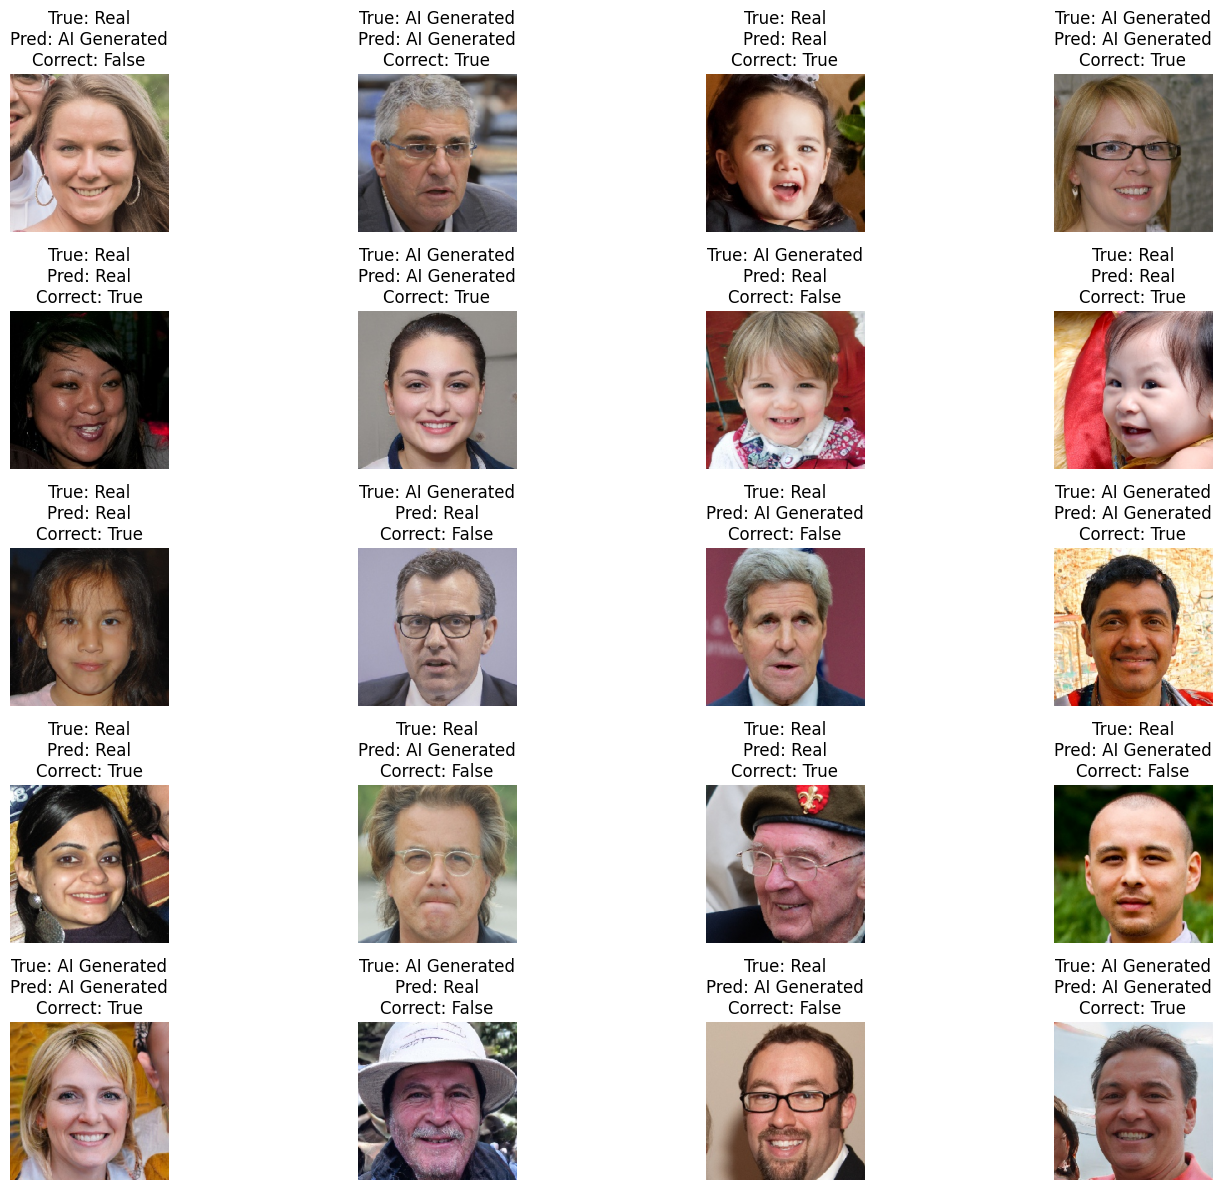

,Image Index,True Label,Predicted Label,Correct
0,0,Real,AI Generated,False
1,1,AI Generated,AI Generated,True
2,2,Real,Real,True
3,3,AI Generated,AI Generated,True
4,4,Real,Real,True
5,5,AI Generated,AI Generated,True
6,6,AI Generated,Real,False
7,7,Real,Real,True
8,8,Real,Real,True
9,9,AI Generated,Real,False


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def show_predictions_table_with_correct_labels(model, generator, num_images = 20, threshold = 0.5):
    images, true_labels = next(generator)
    images, true_labels = images[:num_images], true_labels[:num_images]
    
    predictions = model.predict(images)
    predicted_labels = (predictions >= threshold).astype(int)
  
    if true_labels.ndim > 1:
        true_labels = np.argmax(true_labels, axis=1)
    
    true_label_names = ["Real" if label == 1 else "AI Generated" for label in true_labels]
    predicted_label_names = ["Real" if label == 1 else "AI Generated" for label in predicted_labels]
    correct_predictions = predicted_labels.flatten() == true_labels.flatten()

    df = pd.DataFrame({
        "Image Index": list(range(num_images)),
        "True Label": true_label_names,
        "Predicted Label": predicted_label_names,
        "Correct": correct_predictions
    })

    fig, axes = plt.subplots(5, 4, figsize = (15, 12))

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        ax.set_title(f"True: {df['True Label'][i]}\nPred: {df['Predicted Label'][i]}\nCorrect: {df['Correct'][i]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    return df

show_predictions_table_with_correct_labels(model, val_generator, num_images = 20, threshold = 0.5)

In [10]:
# Unfreeze top 30–40 layers only
for layer in base_model.layers[-40:]:
    layer.trainable = True


In [12]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # very important
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [13]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 556s 171ms/step - accuracy: 0.6628 - loss: 0.8545 - val_accuracy: 0.7710 - val_loss: 0.4791
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 528s 169ms/step - accuracy: 0.7699 - loss: 0.4862 - val_accuracy: 0.7002 - val_loss: 0.6021
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 527s 169ms/step - accuracy: 0.7999 - loss: 0.4380 - val_accuracy: 0.8235 - val_loss: 0.3920
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 527s 169ms/step - accuracy: 0.8177 - loss: 0.4042 - val_accuracy: 0.7650 - val_loss: 0.5122
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 528s 169ms/step - accuracy: 0.8295 - loss: 0.3803 - val_accuracy: 0.8398 - val_loss: 0.3635
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 528s 169ms/step - accuracy: 0.8431 - loss: 0.3601 - val_accuracy: 0.8303 - val_loss: 0.3770
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 538s 172ms/step - accuracy: 0.8519 - loss: 0.3408 - val_accuracy: 0.8661 - val_loss: 0.3209
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 534s 171ms/step - ac

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="binary"
)


Found 100000 images belonging to 2 classes.


In [15]:
train_generator.class_indices


{'fake': 0, 'real': 1}

In [16]:
train_generator.classes


array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.0), 1: np.float64(1.0)}


In [25]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights
)


Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1265s 405ms/step - accuracy: 0.6752 - loss: 0.6030 - val_accuracy: 0.7151 - val_loss: 0.5384
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1270s 406ms/step - accuracy: 0.6909 - loss: 0.5883 - val_accuracy: 0.7426 - val_loss: 0.5142
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1246s 399ms/step - accuracy: 0.6943 - loss: 0.5793 - val_accuracy: 0.7214 - val_loss: 0.5390
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1236s 395ms/step - accuracy: 0.7024 - loss: 0.5709 - val_accuracy: 0.7531 - val_loss: 0.5010
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1242s 397ms/step - accuracy: 0.7089 - loss: 0.5626 - val_accuracy: 0.7660 - val_loss: 0.4876
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1225s 392ms/step - accuracy: 0.7128 - loss: 0.5595 - val_accuracy: 0.7217 - val_loss: 0.5471
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1232s 394ms/step - accuracy: 0.7182 - loss: 0.5522 - val_accuracy: 0.6690 - val_loss: 0.6503
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1237s 396ms/s

In [27]:
model.save("/kaggle/working/resnet50_real_vs_fake.keras")
